In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_validate, cross_val_predict)

from sklearn.tree import (
    DecisionTreeClassifier, DecisionTreeRegressor,
    plot_tree, export_text)

from sklearn.dummy import DummyClassifier, DummyRegressor

from sklearn.metrics import (
    accuracy_score, confusion_matrix, mean_squared_error)

df = pd.read_csv("decision_trees_demo.csv")

features = ["petal_length_cm", "petal_width_cm"]
X = df[features]
y = df["species"]

print("Feature shape:", X.shape, "Target shape:", y.shape)

Feature shape: (150, 2) Target shape: (150,)


Petal length and width are the inputs, and species is the target. Including species in X would give the model the answer.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

assert X_train.index.equals(y_train.index)
assert set(X_train.index).isdisjoint(X_test.index)

train = X_train.assign(species=y_train)

print("Development rows:", len(X_train))
print("Reserved test rows:", len(X_test))

Development rows: 120
Reserved test rows: 30


Changing the model after seeing test results would make the final score less trustworthy.

In [3]:
print(train.head())
print(train.dtypes)
print("Missing values:\n", train.isna().sum())
print(train[features].describe().round(2))

counts = y_train.value_counts().sort_index()
print("Class counts:\n", counts)

majority_accuracy = counts.max() / len(y_train)
print("Majority baseline:", round(majority_accuracy, 3))

print("Two labeled rows per class:\n",
      train.groupby("species").head(2))

     petal_length_cm  petal_width_cm     species
8                1.4             0.2      setosa
106              4.5             1.7   virginica
76               4.8             1.4  versicolor
9                1.5             0.1      setosa
89               4.0             1.3  versicolor
petal_length_cm    float64
petal_width_cm     float64
species             object
dtype: object
Missing values:
 petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64
       petal_length_cm  petal_width_cm
count           120.00          120.00
mean              3.77            1.20
std               1.77            0.76
min               1.10            0.10
25%               1.60            0.30
50%               4.25            1.30
75%               5.10            1.80
max               6.90            2.50
Class counts:
 species
setosa        40
versicolor    40
virginica     40
Name: count, dtype: int64
Majority baseline: 0.333
Two labeled rows per class:
      petal_le

The classes are balanced with no missing values. High accuracy could still mean the model overfit.

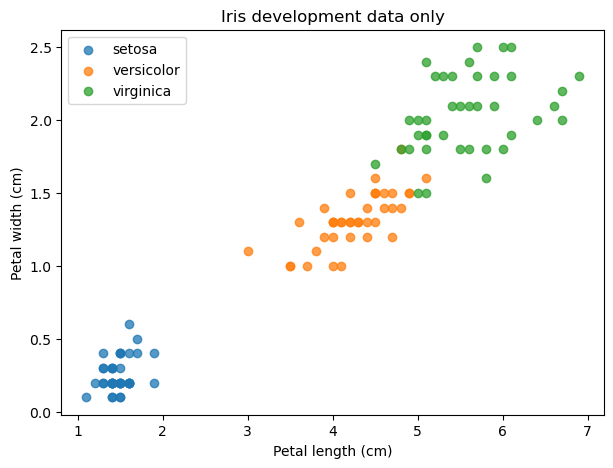

In [4]:
plt.figure(figsize=(7, 5))

for name, group in train.groupby("species"):
    plt.scatter(
        group[features[0]],
        group[features[1]],
        label=name,
        alpha=0.75
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris development data only")
plt.legend()
plt.show()

I would first split where setosa separates from the others. Versicolor and virginica overlap the most.

In [5]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

print("Dummy training accuracy:",
      baseline.score(X_train, y_train))

print("Tree training accuracy:",
      tree.score(X_train, y_train))

print("Depth:", tree.get_depth(),
      "Leaves:", tree.get_n_leaves())

print(export_text(tree, feature_names=features))

Dummy training accuracy: 0.3333333333333333
Tree training accuracy: 0.9666666666666667
Depth: 2 Leaves: 3
|--- petal_length_cm <= 2.45
|   |--- class: setosa
|--- petal_length_cm >  2.45
|   |--- petal_width_cm <= 1.65
|   |   |--- class: versicolor
|   |--- petal_width_cm >  1.65
|   |   |--- class: virginica



One rule separates flowers based on petal width. A deeper tree could memorize the training data.

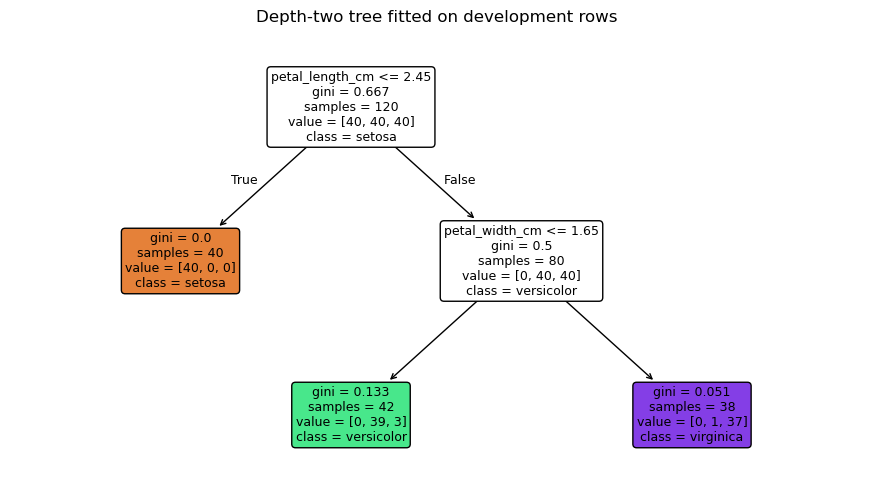

Predicted species: versicolor
Leaf ID: 3


In [6]:
plt.figure(figsize=(11, 6))

plot_tree(
    tree,
    feature_names=features,
    class_names=list(tree.classes_),
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=9
)

plt.title("Depth-two tree fitted on development rows")
plt.show()

flower = pd.DataFrame([[5.0, 1.5]], columns=features)

print("Predicted species:", tree.predict(flower)[0])
print("Leaf ID:", tree.apply(flower)[0])

The tree compares the flower's measurements to its thresholds. A leaf is the final prediction node.

In [7]:
leaf_id = tree.apply(flower)[0]

in_leaf = tree.apply(X_train) == leaf_id

leaf_counts = y_train[in_leaf].value_counts().reindex(
    tree.classes_, fill_value=0)

probabilities = leaf_counts / leaf_counts.sum()

print(pd.DataFrame({
    "count": leaf_counts,
    "probability": probabilities
}))

print("predict_proba:",
      tree.predict_proba(flower)[0])

gini = 1 - np.sum(probabilities.to_numpy() ** 2)

print("Leaf Gini:", round(gini, 3))

assert np.allclose(
    probabilities,
    tree.predict_proba(flower)[0]
)

            count  probability
species                       
setosa          0     0.000000
versicolor     39     0.928571
virginica       3     0.071429
predict_proba: [0.         0.92857143 0.07142857]
Leaf Gini: 0.133


One flower in a leaf gives 100% probability, but one example is not enough to be reliable.

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

candidates = {
    "dummy": DummyClassifier(strategy="most_frequent")
}

for depth in [1, 2, 3, None]:
    for leaf_size in [1, 5]:
        name = f"depth={depth}, leaf={leaf_size}"

        candidates[name] = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf_size,
            random_state=42
        )

rows = []

for name, model in candidates.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    rows.append({
        "model": name,
        "train": scores["train_score"].mean(),
        "validation": scores["test_score"].mean(),
        "spread": scores["test_score"].std()
    })

results = pd.DataFrame(rows).set_index("model")

print(results.round(3))

                    train  validation  spread
model                                        
dummy               0.333       0.333   0.000
depth=1, leaf=1     0.667       0.667   0.000
depth=1, leaf=5     0.667       0.667   0.000
depth=2, leaf=1     0.967       0.950   0.017
depth=2, leaf=5     0.967       0.950   0.017
depth=3, leaf=1     0.979       0.958   0.026
depth=3, leaf=5     0.969       0.950   0.017
depth=None, leaf=1  0.994       0.925   0.031
depth=None, leaf=5  0.969       0.950   0.017


The unrestricted tree has high training accuracy but lower validation accuracy, suggesting overfitting. A simpler tied model is easier to explain.

In [9]:
tree_results = results.drop(index="dummy")

winner = tree_results["validation"].idxmax()

chosen = candidates[winner]

trial = DecisionTreeClassifier(**{
    **chosen.get_params(),
    "criterion": "entropy"
})

trial_scores = cross_validate(
    trial,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

trial_mean = trial_scores["test_score"].mean()

print(
    "Gini:",
    winner,
    tree_results.loc[winner, "validation"]
)

print("Entropy:", trial_mean)

if trial_mean > tree_results.loc[winner, "validation"]:
    chosen = trial
    winner += ", entropy"

frozen_classifier = chosen.fit(X_train, y_train)

print("Frozen classifier:", winner)

Gini: depth=3, leaf=1 0.9583333333333334
Entropy: 0.95
Frozen classifier: depth=3, leaf=1


Gini performed slightly better. The small difference is not enough to say Gini is always better.

In [10]:
oof = cross_val_predict(
    chosen,
    X_train,
    y_train,
    cv=cv
)

labels = list(frozen_classifier.classes_)

matrix = confusion_matrix(
    y_train,
    oof,
    labels=labels
)

print(
    pd.DataFrame(
        matrix,
        index=labels,
        columns=labels
    )
)

mistakes = train.loc[
    y_train.to_numpy() != oof
].copy()

mistakes["predicted"] = oof[
    y_train.to_numpy() != oof
]

print(mistakes.head(8))

            setosa  versicolor  virginica
setosa          40           0          0
versicolor       0          38          2
virginica        0           3         37
     petal_length_cm  petal_width_cm     species   predicted
106              4.5             1.7   virginica  versicolor
70               4.8             1.8  versicolor   virginica
83               5.1             1.6  versicolor   virginica
119              5.0             1.5   virginica  versicolor
126              4.8             1.8   virginica  versicolor


Versicolor and virginica were confused most often, supporting my earlier guess.

             x   target
count  160.000  160.000
mean    -0.002    0.081
std      0.288    0.073
min     -0.493   -0.057
25%     -0.267    0.022
50%     -0.025    0.070
75%      0.258    0.134
max      0.476    0.289


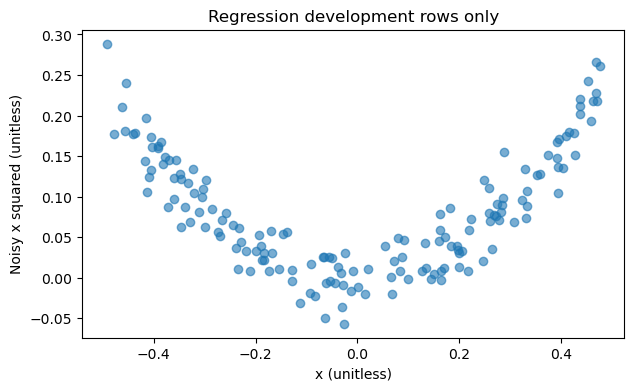

In [11]:
rng = np.random.default_rng(42)

X_reg = pd.DataFrame({
    "x": rng.uniform(-0.5, 0.5, 200)
})

y_reg = (
    X_reg["x"] ** 2
    + rng.normal(0, 0.025, 200)
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(
    Xr_train.assign(target=yr_train)
    .describe()
    .round(3)
)

plt.figure(figsize=(7, 4))

plt.scatter(
    Xr_train["x"],
    yr_train,
    alpha=0.6
)

plt.xlabel("x (unitless)")
plt.ylabel("Noisy x squared (unitless)")
plt.title("Regression development rows only")

plt.show()

Accuracy is for classes, while regression predicts numeric values.

In [12]:
reg_models = {
    "mean": DummyRegressor(strategy="mean"),

    "depth 2": DecisionTreeRegressor(
        max_depth=2,
        random_state=42
    ),

    "unrestricted": DecisionTreeRegressor(
        random_state=42
    ),

    "leaf 10": DecisionTreeRegressor(
        min_samples_leaf=10,
        random_state=42
    )
}

reg_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

reg_scores = {}

for name, model in reg_models.items():

    scores = cross_validate(
        model,
        Xr_train,
        yr_train,
        cv=reg_cv,
        scoring="neg_root_mean_squared_error",
        return_train_score=True
    )

    reg_scores[name] = -scores["test_score"].mean()

    print(
        name,
        "train RMSE",
        -scores["train_score"].mean(),
        "validation RMSE",
        reg_scores[name]
    )

best_reg_name = min(
    reg_scores,
    key=reg_scores.get
)

frozen_regressor = reg_models[
    best_reg_name
].fit(Xr_train, yr_train)

print("Frozen regressor:", best_reg_name)

mean train RMSE 0.07321055940329217 validation RMSE 0.07336208580319721
depth 2 train RMSE 0.039554471880793016 validation RMSE 0.0428943691178364
unrestricted train RMSE -0.0 validation RMSE 0.0354185672010614
leaf 10 train RMSE 0.029427533832485024 validation RMSE 0.03382826586547792
Frozen regressor: leaf 10


No. The unrestricted tree had the lowest training error but not the lowest validation error.

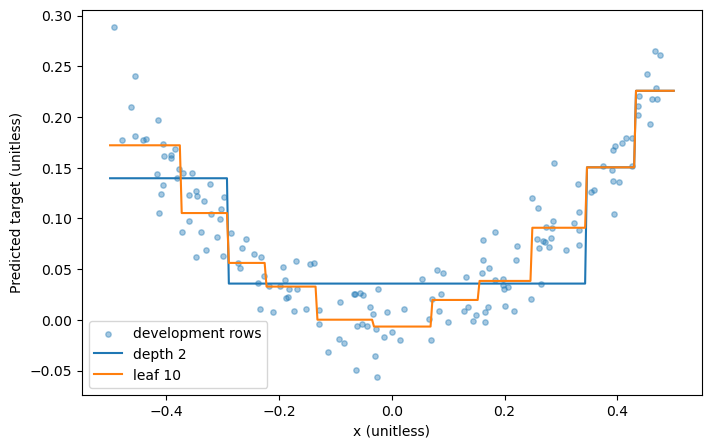

In [13]:
grid = pd.DataFrame({
    "x": np.linspace(-0.5, 0.5, 300)
})

plt.figure(figsize=(8, 5))

plt.scatter(
    Xr_train["x"],
    yr_train,
    s=15,
    alpha=0.4,
    label="development rows"
)

for name in ["depth 2", "leaf 10"]:

    model = reg_models[name].fit(
        Xr_train,
        yr_train
    )

    plt.plot(
        grid["x"],
        model.predict(grid),
        label=name
    )

plt.xlabel("x (unitless)")
plt.ylabel("Predicted target (unitless)")
plt.legend()

plt.show()

The models differ around parts of the curve. For 2, 4, and 9, the prediction would be 5.

In [14]:
final_predictions = frozen_classifier.predict(X_test)

print("Final classifier:", winner)

print(
    "Final test accuracy:",
    accuracy_score(y_test, final_predictions)
)

print(
    "Final dummy accuracy:",
    baseline.score(X_test, y_test)
)

print(
    "Final confusion matrix:\n",
    confusion_matrix(
        y_test,
        final_predictions,
        labels=labels
    )
)

reg_predictions = frozen_regressor.predict(Xr_test)

print("Final regressor:", best_reg_name)

print(
    "Final regression RMSE:",
    mean_squared_error(
        yr_test,
        reg_predictions
    ) ** 0.5
)

reg_baseline = DummyRegressor().fit(
    Xr_train,
    yr_train
)

print(
    "Final mean-baseline RMSE:",
    mean_squared_error(
        yr_test,
        reg_baseline.predict(Xr_test)
    ) ** 0.5
)

Final classifier: depth=3, leaf=1
Final test accuracy: 0.9666666666666667
Final dummy accuracy: 0.3333333333333333
Final confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Final regressor: leaf 10
Final regression RMSE: 0.03345240109117966
Final mean-baseline RMSE: 0.08043607809190362


Both models beat their baselines. The small test sets may not represent future data well.

The classifier was depth=3, leaf=1 with 96.67% accuracy versus 33.33% baseline. The leaf 10 regressor had 0.03345 RMSE versus 0.08044 baseline. Cross-validation was used to choose the models. The small test sets limit how certain the results are.